<a href="https://colab.research.google.com/github/AymaneAmri-MD/drug-design-morphine-paclitaxel/blob/main/notebooks/01_ligand_prep.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01 · Préparation des ligands
Morphine et atropine (L-hyoscyamine) : SMILES isomériques (PubChem), stéréochimie, descripteurs, conformères 3D.

Ce notebook tourne dans **Google Colab** (cellule 1) ou en local avec l'environnement `drug-design`.

In [1]:
# Cellule d'installation (Colab uniquement ; en local, utiliser environment.yml)
import os, sys
if 'google.colab' in sys.modules:
    !pip install -q rdkit
    if not os.path.exists('drug-design-morphine-paclitaxel'):
        !git clone -q https://github.com/AymaneAmri-MD/drug-design-morphine-paclitaxel.git
    %cd drug-design-morphine-paclitaxel/notebooks
os.makedirs('../results', exist_ok=True)
sys.path.append('../src')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.8/31.8 MB 28.5 MB/s eta 0:00:00
/content/drug-design-morphine-paclitaxel/notebooks


In [2]:
import requests
import pandas as pd
from rdkit import Chem, rdBase
from rdkit.Chem import Draw
from ligand_prep import load_mol, describe, embed_conformers, write_best_conformer

print('RDKit', rdBase.rdkitVersion)

RDKit 2026.09.1


## Définition des ligands
Les SMILES isomériques (avec stéréochimie) sont récupérés directement depuis PubChem : par CID pour la morphine (5288826), par nom pour l'atropine.

On utilise le nom **hyoscyamine** (énantiomère L, actif) plutôt qu'« atropine », qui désigne le mélange racémique. Le premier résultat renvoyé par PubChem est utilisé : vérifie qu'il contient bien des `@`.

In [3]:
def pubchem_smiles(ident):
    """SMILES isomérique depuis PubChem, par CID (int) ou par nom (str)."""
    kind = 'cid' if isinstance(ident, int) else 'name'
    url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/{kind}/{ident}/property/IsomericSMILES/TXT"
    r = requests.get(url, timeout=30)
    r.raise_for_status()
    return r.text.strip().splitlines()[0]

IDENTS = {'morphine': 5288826, 'atropine (L-hyoscyamine)': 'hyoscyamine'}
ligands = {name: pubchem_smiles(ident) for name, ident in IDENTS.items()}
for name, smi in ligands.items():
    print(name, '->', smi)
    assert '@' in smi, f'{name} : pas de stéréochimie dans le SMILES'

morphine -> CN1CC[C@]23[C@@H]4[C@H]1CC5=C2C(=C(C=C5)O)O[C@H]3[C@H](C=C4)O
atropine (L-hyoscyamine) -> CN1[C@@H]2CC[C@H]1CC(C2)OC(=O)[C@H](CO)C3=CC=CC=C3


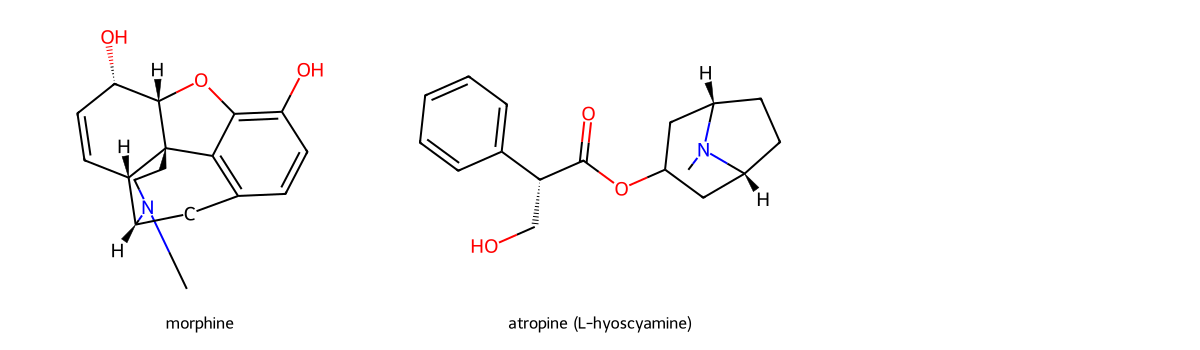

In [4]:
mols = {k: load_mol(v) for k, v in ligands.items()}
Draw.MolsToGridImage(list(mols.values()), legends=list(mols.keys()), subImgSize=(400, 350))

## Descripteurs et contrôle de la stéréochimie
Valeurs attendues : **5 centres chiraux** pour la morphine, **4** pour la L-hyoscyamine (les 3 centres du noyau tropane, dont le C3 dit pseudo-asymétrique que RDKit note en minuscule, et le carbone de l'acide tropique).

Les deux molécules respectent la règle des 5 de Lipinski.

In [5]:
EXPECTED_CHIRAL = {'morphine': 5, 'atropine (L-hyoscyamine)': 4}

table = pd.DataFrame({k: describe(m) for k, m in mols.items()}).T
display(table)

for name, expected in EXPECTED_CHIRAL.items():
    found = table.loc[name, 'centres_chiraux']
    status = 'OK' if found == expected else 'À VÉRIFIER'
    print(f'{name}: {found} centres chiraux (attendu {expected}) -> {status}')

,formule,masse_molaire,logP,HBD,HBA,liaisons_rotatives,centres_chiraux
morphine,C17H19NO3,285.34,1.2,2,4,0,5
atropine (L-hyoscyamine),C17H23NO3,289.38,1.93,1,4,4,4


morphine: 5 centres chiraux (attendu 5) -> OK
atropine (L-hyoscyamine): 4 centres chiraux (attendu 4) -> OK


## Conformères 3D
50 conformères par ligand, optimisation MMFF, seed fixé (42) pour la reproductibilité.
Les énergies MMFF ne se comparent qu'entre conformères d'une même molécule, pas entre molécules.

In [6]:
for name, mol in mols.items():
    safe = name.split()[0]
    molh, ids, energies = embed_conformers(mol, n_confs=50)
    best = write_best_conformer(molh, energies, f'../results/{safe}_best.mol')
    print(f'{name}: {len(ids)} conformères, meilleur = {best}, E = {min(energies):.1f} kcal/mol')

morphine: 50 conformères, meilleur = 26, E = 94.3 kcal/mol
atropine (L-hyoscyamine): 50 conformères, meilleur = 0, E = 49.5 kcal/mol


## Étape suivante
`02_docking.ipynb` : re-docking du ligand co-cristallisé, puis docking morphine → récepteur µ et atropine → récepteur muscarinique M2.